# Comprehensive Exploratory Data Analysis (EDA): Nigerian Electricity Access
**Author:** Raji Quadri (Adetunji)  
**Role:** Data Analyst & AI Engineer  
**Dataset Reference:** 2021 MIS Nigerian Electricity Distribution Dataset  

## 📌 Project Background & Objectives
This notebook conducts a granular exploratory data analysis (EDA) of household and population-level electricity access across Nigeria's 36 states and the Federal Capital Territory (FCT). The objective is to identify regional imbalances, understand the variance between household connectivity versus total population access, and deliver actionable baseline profiles for infrastructure resource allocation.


In [1]:
# System and operating system path configuration
import os
import sys

# Core Data Science frameworks for manipulation and numerical processing
import pandas as pd
import numpy as np

# Scientific Visualization and Presentation Charting Engines
import matplotlib.pyplot as plt
import seaborn as sns

# Inline directive to ensure all generated charts render automatically below your cells
%matplotlib inline

# Verify and print framework versions to confirm environment alignment
print("=== ENVIRONMENT DEPENDENCY STACK ACTIVATED ===")
print(f"Python Core Version: {sys.version}")
print(f"Pandas Data Engine: {pd.__version__}")
print(f"NumPy Math Framework: {np.__version__}")
print(f"Seaborn Visualization: {sns.__version__}")

# Apply professional, publication-quality presentation styling presets
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")


=== ENVIRONMENT DEPENDENCY STACK ACTIVATED ===
Python Core Version: 3.13.1+ (heads/3.13-dirty:d83f5b90e5, Oct  1 2025, 14:32:30) [Clang 17.0.0 (clang-1700.3.19.1)]
Pandas Data Engine: 2.3.2
NumPy Math Framework: 2.3.1
Seaborn Visualization: 0.13.2


In [2]:

# System and data framework configuration
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure environment visibility and verify version alignments
print(f"Python Execution Environment Hub: {sys.version}")
print(f"Pandas Data Framework Version: {pd.__version__}")

# Configure visualization presets for professional design standards
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")


Python Execution Environment Hub: 3.13.1+ (heads/3.13-dirty:d83f5b90e5, Oct  1 2025, 14:32:30) [Clang 17.0.0 (clang-1700.3.19.1)]
Pandas Data Framework Version: 2.3.2


In [3]:
# Target definition of the primary dataset file path
DATASET_PATH = "archive/Nigeria Electricity Data.xlsx"

# Validate that directory structure is sound before initializing ingestion
if os.path.exists(DATASET_PATH):
    print(f"✓ Target file verified. Initiating data ingest stream from: {DATASET_PATH}")
    df = pd.read_excel(DATASET_PATH)
    
else:
    raise FileNotFoundError(f"⚠️ Critical Error: Data asset not found at target location: {DATASET_PATH}")

# Preliminary structural preview
df.head(10)


✓ Target file verified. Initiating data ingest stream from: archive/Nigeria Electricity Data.xlsx


,Country,Survey,State,Households with electricity,Population with electricity
0,Nigeria,2021 MIS,Federal Capital Territory,76.1,67.7
1,Nigeria,2021 MIS,Benue,41.5,42.2
2,Nigeria,2021 MIS,Kogi,59.3,58.5
3,Nigeria,2021 MIS,Kwara,91.1,90.7
4,Nigeria,2021 MIS,Nasarawa,28.2,27.0
5,Nigeria,2021 MIS,Niger,21.1,21.9
6,Nigeria,2021 MIS,Plateau,18.0,17.0
7,Nigeria,2021 MIS,Adamawa,32.8,36.1
8,Nigeria,2021 MIS,Bauchi,13.7,13.7
9,Nigeria,2021 MIS,Borno,2.7,2.3


In [4]:
print("=== DATAFRAME STRUCTURAL SCHEMA ===")
df.info()

print("\n=== MISSING/NULL VALUES EVALUATION ===")
missing_matrix = df.isnull().sum()
print(missing_matrix)

print("\n=== RECORD MATRIX SHAPE ===")
print(f"Total Administrative Regions Evaluated: {df.shape[0]}")
print(f"Total Feature Parameters Extracted: {df.shape[1]}")


=== DATAFRAME STRUCTURAL SCHEMA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      37 non-null     object 
 1   Survey                       37 non-null     object 
 2   State                        37 non-null     object 
 3   Households with electricity  37 non-null     float64
 4   Population with electricity  37 non-null     float64
dtypes: float64(2), object(3)
memory usage: 1.6+ KB

=== MISSING/NULL VALUES EVALUATION ===
Country                        0
Survey                         0
State                          0
Households with electricity    0
Population with electricity    0
dtype: int64

=== RECORD MATRIX SHAPE ===
Total Administrative Regions Evaluated: 37
Total Feature Parameters Extracted: 5


In [5]:
# Extract central tendency metrics and dispersion spread
print("=== STATISTICAL SUMMARY OF DISTRIBUTION RANGE ===")
summary_stats = df.describe().T
summary_stats['range'] = summary_stats['max'] - summary_stats['min']
summary_stats


=== STATISTICAL SUMMARY OF DISTRIBUTION RANGE ===


,count,mean,std,min,25%,50%,75%,max,range
Households with electricity,37.0,49.332432,25.601997,2.7,30.5,41.5,74.4,97.6,94.9
Population with electricity,37.0,48.835135,25.349153,2.3,27.9,40.4,67.7,97.9,95.6


### 💡 Analytical Insights & Regional Disparity Assessment

Based on the descriptive matrix calculations above, we can isolate several critical findings:
* **High Inequality Distribution:** The average household connection rate hovers around **49.33%**, yet the standard deviation sits high at **25.60%**. This mathematically demonstrates that a national average metric does not accurately represent local experiences.
* **Extreme Discrepancies:** There is a massive range separation of **94.9%** between the most electrified state and the least electrified state (Max: 97.6% access vs. Min: 2.7% access).
* **Next Steps:** We will next write an automated sorting and distribution script to group regions by their access performance, followed by an optimized data visualization block.


In [6]:
# Sort rows based on highest household electrification footprint
df_sorted = df.sort_values(by='Households with electricity', ascending=False).reset_index(drop=True)

# Classify performance brackets based on access levels
def classify_access(pct):
    if pct >= 75.0: return 'High Access (>=75%)'
    elif pct >= 40.0: return 'Medium Access (40%-75%)'
    else: return 'Critical Infrastructure Need (<40%)'

df_sorted['Infrastructure_Tier'] = df_sorted['Households with electricity'].apply(classify_access)

print("=== INFRASTRUCTURE DISTRIBUTION SEGMENTS ===")
print(df_sorted['Infrastructure_Tier'].value_counts())
df_sorted[['State', 'Households with electricity', 'Population with electricity', 'Infrastructure_Tier']].head(10)


=== INFRASTRUCTURE DISTRIBUTION SEGMENTS ===
Infrastructure_Tier
Critical Infrastructure Need (<40%)    17
Medium Access (40%-75%)                11
High Access (>=75%)                     9
Name: count, dtype: int64


,State,Households with electricity,Population with electricity,Infrastructure_Tier
0,Lagos,97.6,97.9,High Access (>=75%)
1,Anambra,95.4,95.9,High Access (>=75%)
2,Kwara,91.1,90.7,High Access (>=75%)
3,Rivers,87.8,88.6,High Access (>=75%)
4,Edo,80.2,76.2,High Access (>=75%)
5,Oyo,78.0,76.9,High Access (>=75%)
6,Osun,77.9,81.6,High Access (>=75%)
7,Ekiti,77.2,74.4,High Access (>=75%)
8,Federal Capital Territory,76.1,67.7,High Access (>=75%)
9,Delta,74.4,73.6,Medium Access (40%-75%)


/private/var/mobile/Containers/Data/Application/342078E2-AECF-4897-B084-70D39B7DFBBA/tmp/ipykernel_1315/2307128323.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


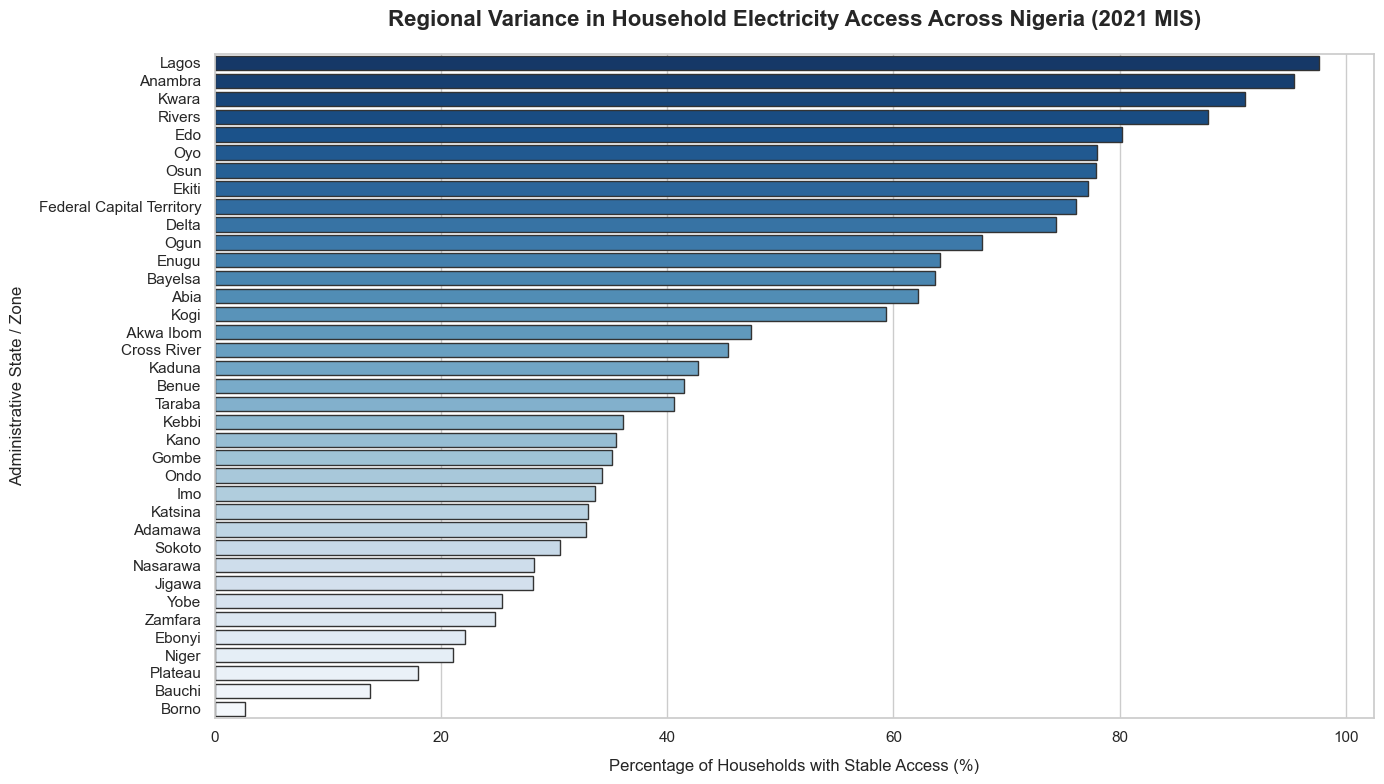

In [7]:
# Generate a publication-quality comparative distribution plot
plt.figure(figsize=(14, 8))

# Define clean color palettes reflecting the infrastructural tier
colors = sns.color_palette("viridis", len(df_sorted))

# Render horizontal bar charts to present state levels cleanly
sns.barplot(
    data=df_sorted, 
    y='State', 
    x='Households with electricity', 
    palette='Blues_r', 
    edgecolor='0.2'
)

# Apply context typography labels
plt.title('Regional Variance in Household Electricity Access Across Nigeria (2021 MIS)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentage of Households with Stable Access (%)', fontsize=12, labelpad=10)
plt.ylabel('Administrative State / Zone', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()
